In [1]:
# Import libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Date & Time
from datetime import datetime

In [2]:
# Load dataset

df = pd.read_csv('traffic.csv')

# Show first 5 rows
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print(df.columns)

# Dataset info
df.info()

Dataset Shape: (39290, 9)
Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39290 entries, 0 to 39289
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   event    39290 non-null  object
 1   date     39290 non-null  object
 2   country  39289 non-null  object
 3   city     39289 non-null  object
 4   artist   39284 non-null  object
 5   album    39289 non-null  object
 6   track    39289 non-null  object
 7   isrc     37706 non-null  object
 8   linkid   39289 non-null  object
dtypes: object(9)
memory usage: 2.7+ MB


In [4]:
# Missing values

df.isnull().sum()

,0
event,0
date,0
country,1
city,1
artist,6
album,1
track,1
isrc,1584
linkid,1


In [7]:
# Remove duplicates

df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [9]:
print(df.columns)

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')


In [10]:
# Convert date column into datetime format

df['date'] = pd.to_datetime(df['date'])

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [11]:
# Extract day, month and year

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df.head()

,event,date,country,city,artist,album,track,isrc,linkid,day,month,year
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,21,8,2021
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2,21,8,2021
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd,21,8,2021
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,21,8,2021
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02,21,8,2021


In [12]:
# Total website events

print("Total Events:", len(df))

Total Events: 24695


In [13]:
top_countries = df['country'].value_counts().head(10)

print(top_countries)

country
United States     6110
India             4309
France            2069
Saudi Arabia      1658
United Kingdom     927
Germany            766
Canada             614
Pakistan           584
Iraq               463
Australia          372
Name: count, dtype: int64


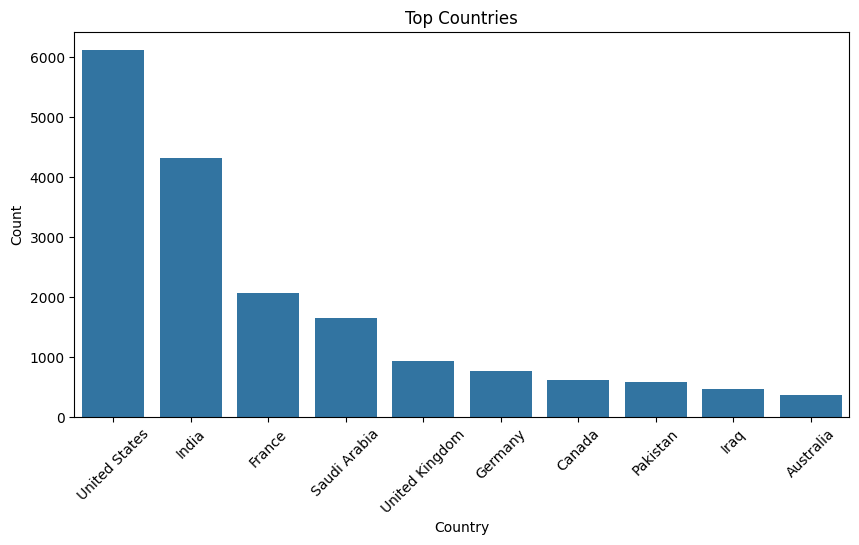

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title('Top Countries')
plt.xlabel('Country')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [15]:
top_cities = df['city'].value_counts().head(10)

print(top_cities)

city
Unknown      1895
Jeddah        592
Riyadh        532
Hyderabad     261
Jaipur        234
Lucknow       231
Delhi         214
Dammam        203
Ahmedabad     201
Bengaluru     200
Name: count, dtype: int64


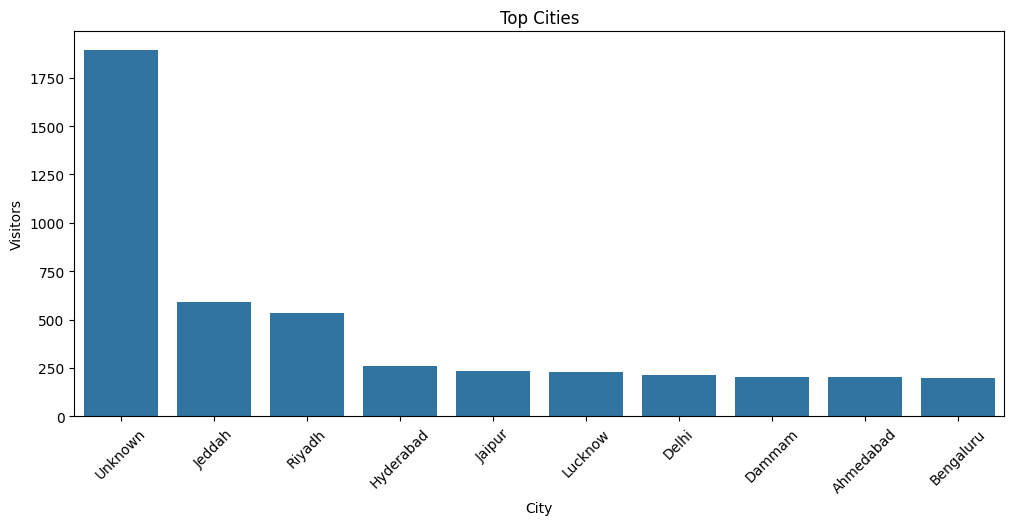

In [16]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)

plt.title('Top Cities')
plt.xlabel('City')
plt.ylabel('Visitors')

plt.xticks(rotation=45)

plt.show()

In [17]:
top_artists = df['artist'].value_counts().head(10)

print(top_artists)

artist
Tesher                                                          1814
Tundra Beats                                                     821
Anne-Marie                                                       756
Roddy Ricch                                                      691
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna     676
Surf Mesa, Emilee                                                537
Reyanna Maria                                                    524
Olivia Rodrigo                                                   494
PinkPantheress                                                   472
Shawn Mendes, Tainy                                              455
Name: count, dtype: int64


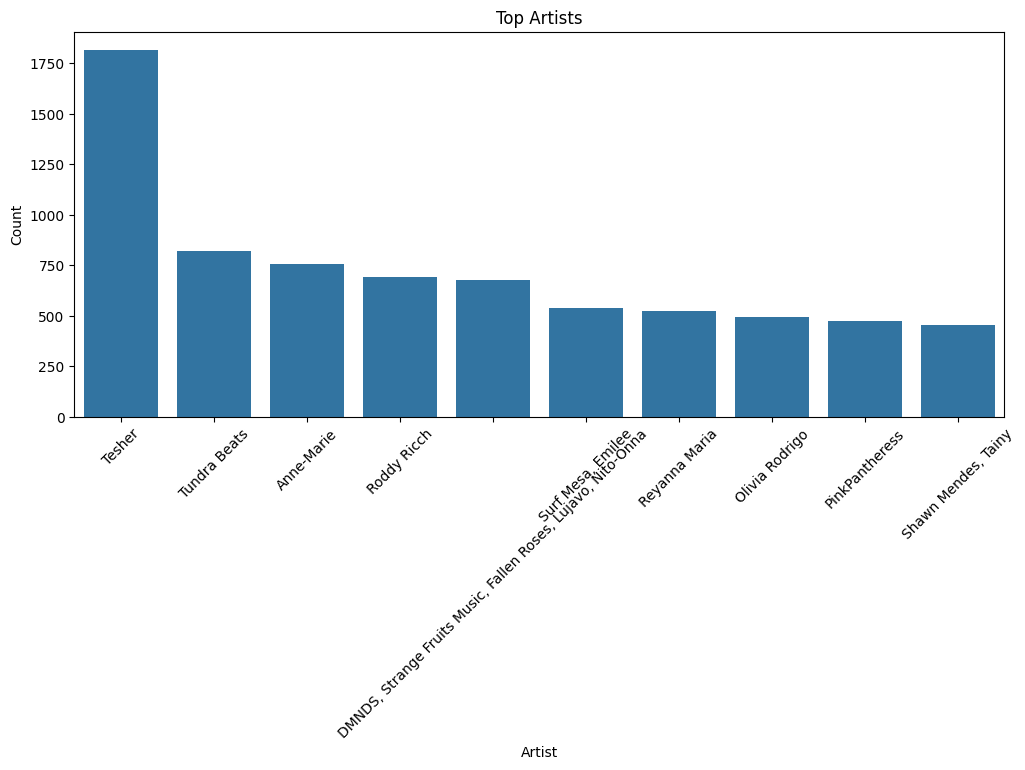

In [18]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_artists.index,
    y=top_artists.values
)

plt.title('Top Artists')
plt.xlabel('Artist')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [19]:
top_albums = df['album'].value_counts().head(10)

print(top_albums)

album
Jalebi Baby                             1814
Beautiful Day                            821
Beautiful                                756
Calabria (feat. Lujavo & Nito-Onna)      676
Late At Night                            676
So Pretty                                554
ily (i love you baby) (feat. Emilee)     537
The Massacre                             514
SOUR                                     467
Summer Of Love                           455
Name: count, dtype: int64


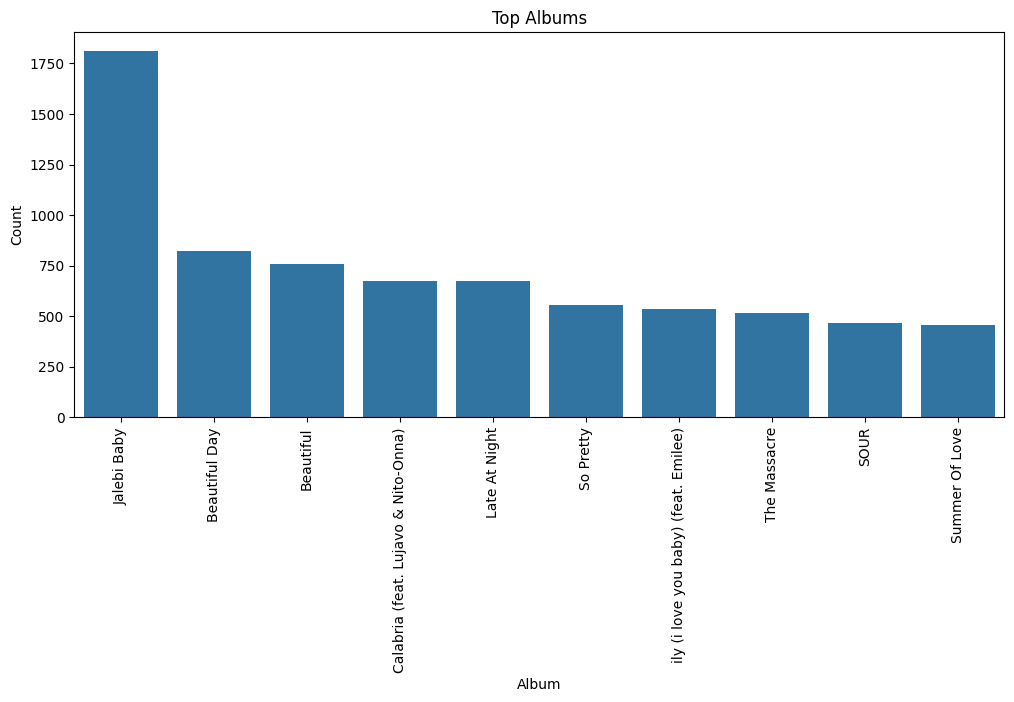

In [20]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_albums.index,
    y=top_albums.values
)

plt.title('Top Albums')
plt.xlabel('Album')
plt.ylabel('Count')

plt.xticks(rotation=90)

plt.show()

In [21]:
top_tracks = df['track'].value_counts().head(10)

print(top_tracks)

track
Jalebi Baby                              1814
Beautiful Day                             821
Beautiful                                 757
Late At Night                             676
Calabria (feat. Lujavo & Nito-Onna)       676
So Pretty                                 554
ily (i love you baby) (feat. Emilee)      537
Summer of Love (Shawn Mendes & Tainy)     455
Candy Shop                                432
I'm Perfect                               406
Name: count, dtype: int64


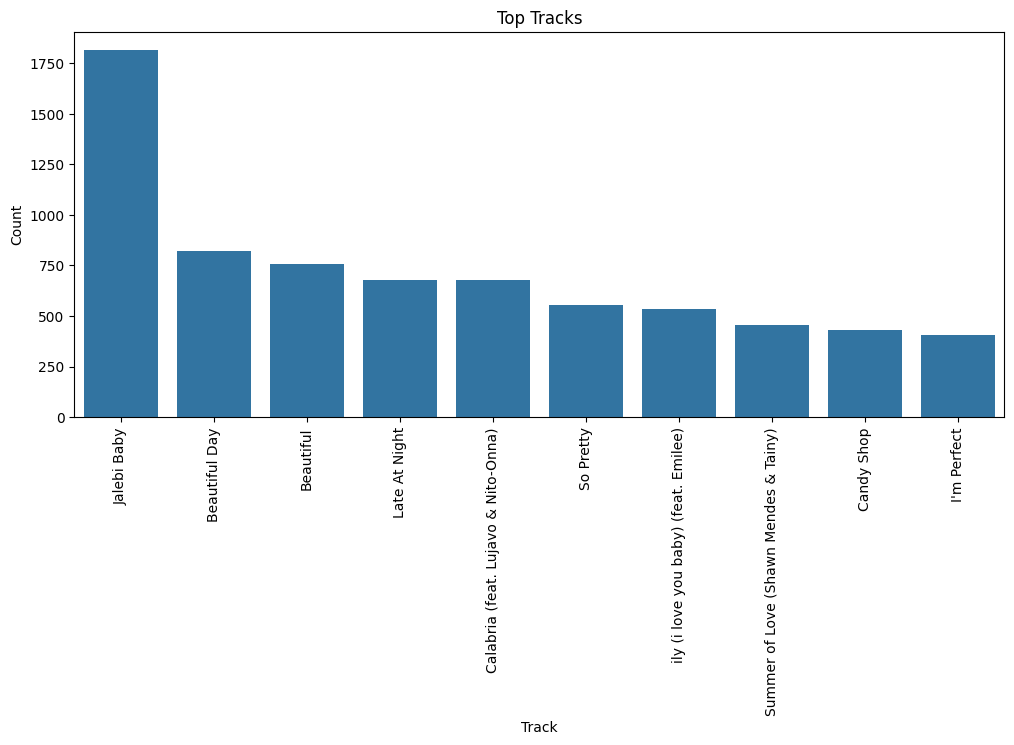

In [22]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_tracks.index,
    y=top_tracks.values
)

plt.title('Top Tracks')
plt.xlabel('Track')
plt.ylabel('Count')

plt.xticks(rotation=90)

plt.show()

In [23]:
daily_traffic = df.groupby('date').size()

print(daily_traffic.head())

date
2021-08-19    4422
2021-08-20    3856
2021-08-21    3221
2021-08-22    3321
2021-08-23    3286
dtype: int64


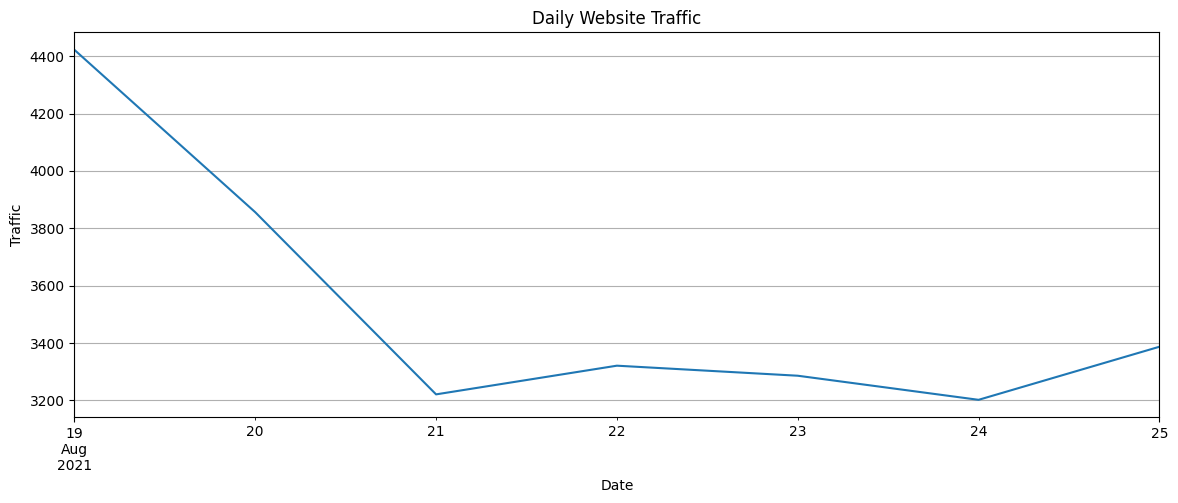

In [24]:
plt.figure(figsize=(14,5))

daily_traffic.plot()

plt.title('Daily Website Traffic')
plt.xlabel('Date')
plt.ylabel('Traffic')

plt.grid(True)

plt.show()

In [25]:
country_users = df.groupby('country')['linkid'].nunique().sort_values(ascending=False).head(10)

print(country_users)

country
United States     1376
India              313
Saudi Arabia       282
France             252
Canada             246
United Kingdom     199
Germany            178
Pakistan           142
Turkey             125
Australia          119
Name: linkid, dtype: int64


In [26]:
event_counts = df['event'].value_counts()

print(event_counts)

event
click    24695
Name: count, dtype: int64


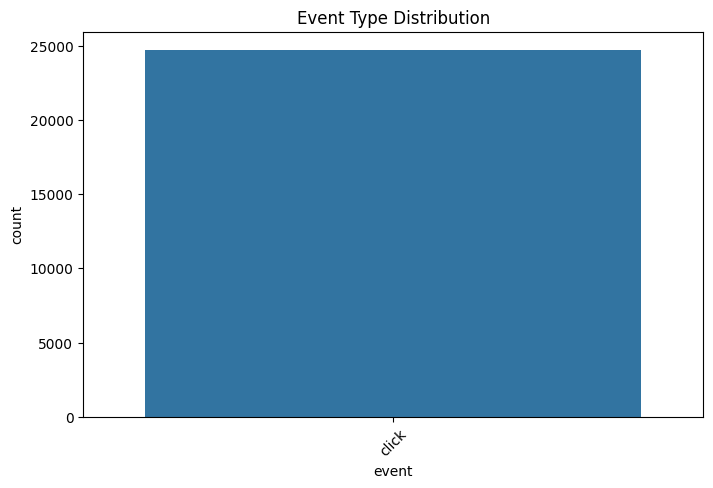

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(x='event', data=df)

plt.title('Event Type Distribution')

plt.xticks(rotation=45)

plt.show()